In [1]:
import torch
import librosa
import transformers
import numpy
import pandas

print("Environment ready ✅")

c:\Users\Varad\anaconda3\envs\sermp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment ready ✅


In [6]:
import os
import pandas as pd
import librosa
import numpy as np


# -------------------------------------------------
# Create RAVDESS dataset (paths + emotion labels)
# -------------------------------------------------
def create_ravdess_dataset(directory_path):

    emotion_map = {
        '01': 'neutral',
        '02': 'calm',
        '03': 'happy',
        '04': 'sad',
        '05': 'angry',
        '06': 'fearful',
        '07': 'disgust',
        '08': 'surprised'
    }

    dataset = []

    for subdir, _, files in os.walk(directory_path):
        for file in files:

            if not file.lower().endswith(".wav"):
                continue

            parts = file.split("-")

            if len(parts) < 7:
                continue

            vocal_channel = parts[1]
            emotion_code = parts[2]

            if vocal_channel != "01":
                continue

            if emotion_code in emotion_map:

                dataset.append({
                    "path": os.path.join(subdir, file),
                    "emotion": emotion_map[emotion_code]
                })

    return dataset


# -------------------------------------------------
# FORMANT EXTRACTION (stable LPC frame-based)
# -------------------------------------------------
def extract_formants(y, sr, n_formants=3):
    try:
        # 1. Pre-emphasis
        y = librosa.effects.preemphasis(y)

        # 2. Frame parameters
        frame_length = int(0.025 * sr)
        hop_length = int(0.010 * sr)

        frames = librosa.util.frame(
            y,
            frame_length=frame_length,
            hop_length=hop_length
        )

        # Generate a window function to prevent edge discontinuities
        window = np.hamming(frame_length)
        
        formant_values = []

        for frame in frames.T:
            # 3. Energy check (skip silence and highly unvoiced frames)
            if np.max(np.abs(frame)) < 0.02:
                continue

            # Apply the window to the frame BEFORE calculating LPC
            windowed_frame = frame * window

            order = 2 + sr // 1000
            lpc_coeffs = librosa.lpc(windowed_frame, order=order)

            # 4. Find roots and keep only positive imaginary parts
            roots = np.roots(lpc_coeffs)
            roots = roots[np.imag(roots) > 0] 

            # Calculate frequencies
            angles = np.arctan2(np.imag(roots), np.real(roots))
            freqs = angles * (sr / (2 * np.pi))

            # 5. Calculate Bandwidths
            # Formula: B = -(sr / pi) * ln(|r|)
            bws = -(sr / np.pi) * np.log(np.abs(roots))

            # 6. Filter by frequency range AND bandwidth
            valid_formants = []
            for f, bw in zip(freqs, bws):
                # A bandwidth > 400Hz usually means it's spectral tilt, not a formant
                if 90 < f < 5000 and bw < 400:
                    valid_formants.append(f)

            valid_formants = sorted(valid_formants)

            if len(valid_formants) >= n_formants:
                formant_values.append(valid_formants[:n_formants])

        if len(formant_values) == 0:
            return [0.0] * n_formants

        # Return the mean of the tracked formants over valid frames
        return np.mean(formant_values, axis=0).tolist()

    except Exception as e:
        # Actually print the error so you know if something breaks
        print(f"Formant extraction failed: {e}")
        return [0.0] * n_formants


# -------------------------------------------------
# FEATURE EXTRACTION
# -------------------------------------------------
def extract_features(df, n_mfcc=13, lpc_order=12):

    features = []

    for idx, row in df.iterrows():

        try:

            path = row["path"]

            if not os.path.exists(path):
                continue

            y, sr = librosa.load(path, sr=16000)

            if len(y) == 0:
                continue


            # =====================
            # MFCC
            # =====================
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

            mfcc_mean = np.mean(mfcc, axis=1)
            mfcc_std = np.std(mfcc, axis=1)


            # =====================
            # CHROMAGRAM
            # =====================
            chroma = librosa.feature.chroma_stft(y=y, sr=sr)

            chroma_mean = np.mean(chroma, axis=1)
            chroma_std = np.std(chroma, axis=1)


            # =====================
            # LPC
            # =====================
            lpc_coeffs = librosa.lpc(y, order=lpc_order)


            # =====================
            # FORMANTS
            # =====================
            formants = extract_formants(y, sr)


            features.append({

                "path": path,   # IMPORTANT FIX
                "emotion": row["emotion"],

                "mfcc_mean": mfcc_mean,
                "mfcc_std": mfcc_std,

                "chroma_mean": chroma_mean,
                "chroma_std": chroma_std,

                "lpc": lpc_coeffs,
                "formants": formants
            })

            print(f"Processed {idx+1}: {os.path.basename(path)}")

        except Exception as e:

            print(f"Error processing {path}: {e}")

    return features


# -------------------------------------------------
# MAIN SCRIPT
# -------------------------------------------------
ravdess_path = "ravedess-emotional-speech-audio"

ravdess_data = create_ravdess_dataset(ravdess_path)

df_ravdess = pd.DataFrame(ravdess_data)

print("Total samples:", len(df_ravdess))


# Extract features
extracted_features = extract_features(df_ravdess)


# -------------------------------------------------
# FLATTEN FEATURES
# -------------------------------------------------
flattened_features = []

for item in extracted_features:

    row = {
        "path": item["path"],
        "emotion": item["emotion"]
    }

    # MFCC
    for i, v in enumerate(item["mfcc_mean"]):
        row[f"mfcc_mean_{i}"] = v

    for i, v in enumerate(item["mfcc_std"]):
        row[f"mfcc_std_{i}"] = v


    # CHROMA
    for i, v in enumerate(item["chroma_mean"]):
        row[f"chroma_mean_{i}"] = v

    for i, v in enumerate(item["chroma_std"]):
        row[f"chroma_std_{i}"] = v


    # LPC
    for i, v in enumerate(item["lpc"]):
        row[f"lpc_{i}"] = v


    # FORMANTS
    for i, v in enumerate(item["formants"]):
        row[f"formant_{i+1}"] = v


    flattened_features.append(row)


df_features = pd.DataFrame(flattened_features)

csv_filename = "ser_features_mfcc_chroma_lpc_formants.csv"

df_features.to_csv(csv_filename, index=False)


print("\nFeature extraction complete")
print("Saved to:", csv_filename)
print("Shape:", df_features.shape)

Total samples: 2880
Processed 1: 03-01-01-01-01-01-01.wav
Processed 2: 03-01-01-01-01-02-01.wav
Processed 3: 03-01-01-01-02-01-01.wav
Processed 4: 03-01-01-01-02-02-01.wav
Processed 5: 03-01-02-01-01-01-01.wav
Processed 6: 03-01-02-01-01-02-01.wav
Processed 7: 03-01-02-01-02-01-01.wav
Processed 8: 03-01-02-01-02-02-01.wav
Processed 9: 03-01-02-02-01-01-01.wav
Processed 10: 03-01-02-02-01-02-01.wav
Processed 11: 03-01-02-02-02-01-01.wav
Processed 12: 03-01-02-02-02-02-01.wav
Processed 13: 03-01-03-01-01-01-01.wav
Processed 14: 03-01-03-01-01-02-01.wav
Processed 15: 03-01-03-01-02-01-01.wav
Processed 16: 03-01-03-01-02-02-01.wav
Processed 17: 03-01-03-02-01-01-01.wav
Processed 18: 03-01-03-02-01-02-01.wav
Processed 19: 03-01-03-02-02-01-01.wav
Processed 20: 03-01-03-02-02-02-01.wav
Processed 21: 03-01-04-01-01-01-01.wav
Processed 22: 03-01-04-01-01-02-01.wav
Processed 23: 03-01-04-01-02-01-01.wav
Processed 24: 03-01-04-01-02-02-01.wav
Processed 25: 03-01-04-02-01-01-01.wav
Processed 26: 

In [3]:
import torch
import pandas as pd
import numpy as np
import torchaudio
import os

from transformers import Wav2Vec2Model
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ========================
# CONFIG
# ========================
CSV_PATH = "ser_features_mfcc_chroma_lpc_formants.csv"
OUTPUT_FEATURES = "ser_fused_features.npy"
OUTPUT_LABELS = "ser_labels.npy"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_AUDIO_LEN = 16000 * 5


# ========================
# LOAD CSV
# ========================
df = pd.read_csv(CSV_PATH)

if "path" not in df.columns:
    raise ValueError("CSV must contain 'path' column")

paths = df["path"].values
labels = df["emotion"]

X_acoustic = df.drop(columns=["emotion", "path"])

scaler = StandardScaler()
X_acoustic = scaler.fit_transform(X_acoustic)

encoder = LabelEncoder()
y = encoder.fit_transform(labels)


# ========================
# LOAD WAV2VEC2
# ========================
wav2vec = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base"
).to(DEVICE)

wav2vec.eval()


# ========================
# AUDIO LOADER
# ========================
def load_audio(path):

    waveform, sr = torchaudio.load(path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0)
    else:
        waveform = waveform.squeeze(0)

    waveform = waveform.flatten()

    if len(waveform) > MAX_AUDIO_LEN:
        waveform = waveform[:MAX_AUDIO_LEN]
    else:
        pad = MAX_AUDIO_LEN - len(waveform)
        waveform = torch.nn.functional.pad(waveform, (0, pad))

    return waveform


# ========================
# EXTRACT EMBEDDINGS
# ========================
wav_embeddings = []

print("Extracting Wav2Vec2 embeddings...")

with torch.no_grad():

    for i, path in enumerate(paths):

        audio = load_audio(path).to(DEVICE)

        audio = (audio - audio.mean()) / (audio.std() + 1e-7)

        output = wav2vec(audio.unsqueeze(0))

        embed = output.last_hidden_state.mean(dim=1)

        wav_embeddings.append(embed.squeeze().cpu().numpy())

        if i % 50 == 0:
            print(f"{i}/{len(paths)} processed")


wav_embeddings = np.array(wav_embeddings)


# ========================
# MERGE FEATURES
# ========================
X = np.concatenate([X_acoustic, wav_embeddings], axis=1)


# ========================
# SAVE DATA
# ========================
np.save(OUTPUT_FEATURES, X)
np.save(OUTPUT_LABELS, y)

print("Saved fused dataset:")
print("Features:", X.shape)
print("Labels:", y.shape)

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 15071.49it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting Wav2Vec2 embeddings...
0/2880 processed
50/2880 processed
100/2880 processed
150/2880 processed
200/2880 processed
250/2880 processed
300/2880 processed
350/2880 processed
400/2880 processed
450/2880 processed
500/2880 processed
550/2880 processed
600/2880 processed
650/2880 processed
700/2880 processed
750/2880 processed
800/2880 processed
850/2880 processed
900/2880 processed
950/2880 processed
1000/2880 processed
1050/2880 processed
1100/2880 processed
1150/2880 processed
1200/2880 processed
1250/2880 processed
1300/2880 processed
1350/2880 processed
1400/2880 processed
1450/2880 processed
1500/2880 processed
1550/2880 processed
1600/2880 processed
1650/2880 processed
1700/2880 processed
1750/2880 processed
1800/2880 processed
1850/2880 processed
1900/2880 processed
1950/2880 processed
2000/2880 processed
2050/2880 processed
2100/2880 processed
2150/2880 processed
2200/2880 processed
2250/2880 processed
2300/2880 processed
2350/2880 processed
2400/2880 processed
2450/2880


===== Fold 1 =====
Epoch 1 | Train 0.3008 | Val 0.4514
Epoch 2 | Train 0.4909 | Val 0.5729
Epoch 3 | Train 0.6094 | Val 0.6285
Epoch 4 | Train 0.7031 | Val 0.6910
Epoch 5 | Train 0.7839 | Val 0.7778
Epoch 6 | Train 0.8303 | Val 0.7778
Epoch 7 | Train 0.8754 | Val 0.8125
Epoch 8 | Train 0.9175 | Val 0.8663
Epoch 9 | Train 0.9327 | Val 0.8993
Epoch 10 | Train 0.9488 | Val 0.9149
Epoch 11 | Train 0.9553 | Val 0.9340
Epoch 12 | Train 0.9783 | Val 0.9306
Epoch 13 | Train 0.9826 | Val 0.9323
Epoch 14 | Train 0.9865 | Val 0.9167
Epoch 15 | Train 0.9861 | Val 0.9288
Epoch 16 | Train 0.9852 | Val 0.9340
Epoch 17 | Train 0.9957 | Val 0.9375
Epoch 18 | Train 0.9978 | Val 0.9444
Epoch 19 | Train 0.9983 | Val 0.9514
Epoch 20 | Train 0.9957 | Val 0.9427
Epoch 21 | Train 0.9983 | Val 0.9531
Epoch 22 | Train 0.9974 | Val 0.9479
Epoch 23 | Train 0.9991 | Val 0.9531
Epoch 24 | Train 0.9978 | Val 0.9479
Epoch 25 | Train 1.0000 | Val 0.9583
Epoch 26 | Train 0.9983 | Val 0.9479
Epoch 27 | Train 0.9987 | V

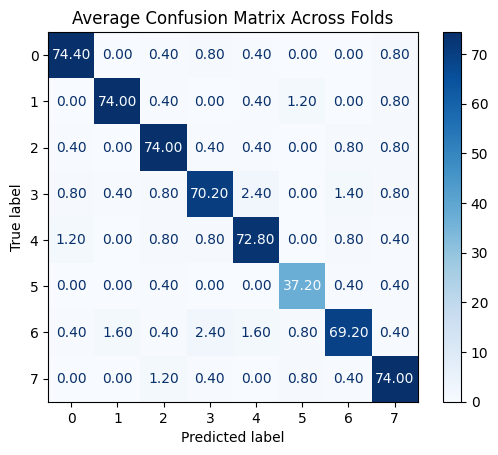

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import Dataset, DataLoader


# ========================
# CONFIG
# ========================
FEATURE_PATH = "ser_fused_features.npy"
LABEL_PATH = "ser_labels.npy"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 16
EPOCHS = 60
LR = 1e-4
KFOLDS = 5
PATIENCE = 8


# ========================
# LOAD DATA
# ========================
X = np.load(FEATURE_PATH)
y = np.load(LABEL_PATH)

NUM_CLASSES = len(np.unique(y))


# ========================
# DATASET CLASS
# ========================
class SERDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.long)
        )


# ========================
# MODEL
# ========================
class FusionClassifier(nn.Module):

    def __init__(self, input_dim, num_classes):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        return self.net(x)


# ========================
# KFOLD TRAINING
# ========================
kfold = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=42)

fold_results = []
conf_matrix_sum = np.zeros((NUM_CLASSES, NUM_CLASSES))


for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):

    print(f"\n===== Fold {fold+1} =====")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    train_loader = DataLoader(
        SERDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        SERDataset(X_val, y_val),
        batch_size=BATCH_SIZE
    )


    model = FusionClassifier(
        input_dim=X.shape[1],
        num_classes=NUM_CLASSES
    ).to(DEVICE)


    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=LR)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )


    best_val = 0
    patience_counter = 0


    # ========================
    # TRAIN LOOP
    # ========================
    for epoch in range(EPOCHS):

        model.train()

        train_correct = 0

        for features, labels in train_loader:

            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(features)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            preds = torch.argmax(outputs, dim=1)

            train_correct += (preds == labels).sum().item()


        train_acc = train_correct / len(X_train)


        # ========================
        # VALIDATION
        # ========================
        model.eval()

        val_correct = 0

        all_preds = []
        all_targets = []

        with torch.no_grad():

            for features, labels in val_loader:

                features = features.to(DEVICE)

                outputs = model(features)

                preds = torch.argmax(outputs, dim=1)

                val_correct += (preds.cpu() == labels).sum().item()

                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(labels.numpy())


        val_acc = val_correct / len(X_val)

        scheduler.step(val_acc)


        print(
            f"Epoch {epoch+1} | Train {train_acc:.4f} | Val {val_acc:.4f}"
        )


        # ========================
        # EARLY STOPPING
        # ========================
        if val_acc > best_val:

            best_val = val_acc

            best_preds = all_preds
            best_targets = all_targets

            patience_counter = 0

        else:

            patience_counter += 1

            if patience_counter >= PATIENCE:

                print("Early stopping triggered")

                break


    fold_results.append(best_val)


    # ========================
    # CONFUSION MATRIX
    # ========================
    cm = confusion_matrix(best_targets, best_preds)

    conf_matrix_sum += cm


# ========================
# FINAL RESULTS
# ========================
print("\nKFold Results:")

for i, score in enumerate(fold_results):

    print(f"Fold {i+1}: {score:.4f}")

print("Mean Accuracy:", np.mean(fold_results))


# ========================
# MEAN CONFUSION MATRIX
# ========================
conf_matrix_avg = conf_matrix_sum / KFOLDS

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_avg)

disp.plot(cmap="Blues", values_format=".2f")

plt.title("Average Confusion Matrix Across Folds")

plt.show()